# Many-to-Many LSTM Scoring Evaluation

В этом ноутбуке анализируется базовая many-to-many LSTM модель для HDFS anomaly detection. Архитектура намеренно сопоставима с one-step baseline: `embedding_dim = 32`, `hidden_size = 64`, `num_layers = 1`. Это позволяет оценить именно влияние scoring strategy, не смешивая его с увеличением размера модели.

Модель предсказывает следующий `EventId` для каждой позиции внутри окна. Далее эти предсказания агрегируются в block-level anomaly score разными способами: `topk_last`, `topk_all`, `topk_last3`, `nll_mean`, `nll_p95`, `nll_max`.

## 1 Импорты и пути

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import precision_recall_curve

plt.style.use('default')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 180)


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for path in (current, *current.parents):
        if (path / 'configs').exists() and (path / 'src').exists():
            return path
    raise RuntimeError('Project root not found')


ROOT = find_project_root()
RUN_NAME = 'token_all_e32_h64_l1_d00'
REPORT_DIR = ROOT / 'reports' / 'lstm_many_to_many' / RUN_NAME
TABLE_DIR = REPORT_DIR / 'tables'
FIG_DIR = REPORT_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

STRATEGIES = ['topk_last', 'topk_all', 'topk_last3', 'nll_mean', 'nll_p95', 'nll_max']

print('ROOT:', ROOT)
print('RUN:', RUN_NAME)
print('TABLE_DIR:', TABLE_DIR)

ROOT: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection
RUN: token_all_e32_h64_l1_d00
TABLE_DIR: /Users/andrew/PycharmProjects/hdfs-log-anomaly-detection/reports/lstm_many_to_many/token_all_e32_h64_l1_d00/tables


## 2 Загрузка результатов

In [2]:
validation_metrics = pd.read_csv(TABLE_DIR / 'lstm_many_to_many_validation_metrics.csv')
test_metrics = pd.read_csv(TABLE_DIR / 'lstm_many_to_many_test_metrics.csv')
thresholds = pd.read_csv(TABLE_DIR / 'lstm_many_to_many_thresholds.csv')

with (TABLE_DIR / 'lstm_many_to_many_history.json').open('r', encoding='utf-8') as file:
    history = json.load(file)

scores = {
    split: {
        strategy: pd.read_csv(TABLE_DIR / f'scores_{split}_{strategy}_lstm_many_to_many.csv')
        for strategy in STRATEGIES
    }
    for split in ['val', 'test']
}

metrics = pd.concat(
    [validation_metrics.assign(split='validation'), test_metrics.assign(split='test')],
    ignore_index=True,
)
metric_columns = ['split', 'strategy', 'threshold', 'f1', 'precision', 'recall', 'fpr', 'average_precision', 'tn', 'fp', 'fn', 'tp']
display(metrics[metric_columns].sort_values(['split', 'f1'], ascending=[True, False]).round(4))
display(thresholds.round(4))

print('Best epoch:', history.get('best_epoch'))
print('Best val_loss:', round(history.get('best_val_loss'), 4))
print('Test score rows:', {strategy: frame.shape[0] for strategy, frame in scores['test'].items()})

,split,strategy,threshold,f1,precision,recall,fpr,average_precision,tn,fp,fn,tp
11,test,nll_max,8.4257,0.8871,0.9625,0.8227,0.0043,0.9509,55583,240,1326,6154
8,test,topk_last3,0.0784,0.6281,0.7017,0.5684,0.0324,0.5975,54015,1808,3228,4252
7,test,topk_all,0.0909,0.5756,0.7671,0.4606,0.0187,0.6267,54777,1046,4035,3445
6,test,topk_last,0.1034,0.5699,0.8529,0.4279,0.0099,0.5607,55271,552,4279,3201
10,test,nll_p95,5.5183,0.5506,0.8582,0.4053,0.0090,0.6443,55322,501,4448,3032
9,test,nll_mean,1.0443,0.5350,0.8564,0.3890,0.0087,0.6613,55335,488,4570,2910
5,validation,nll_max,8.4257,0.8697,0.9152,0.8285,0.0044,0.9101,55579,243,543,2624
0,validation,topk_last,0.1034,0.5350,0.7075,0.4301,0.0101,0.4476,55259,563,1805,1362
4,validation,nll_p95,5.5183,0.5301,0.7212,0.4190,0.0092,0.5419,55309,513,1840,1327
1,validation,topk_all,0.0909,0.5177,0.5778,0.4689,0.0194,0.5006,54737,1085,1682,1485


,model,strategy,threshold_strategy,threshold,validation_best_f1
0,lstm_many_to_many_topk_last,topk_last,max_f1,0.1034,0.5350
1,lstm_many_to_many_topk_all,topk_all,max_f1,0.0909,0.5177
2,lstm_many_to_many_topk_last3,topk_last3,max_f1,0.0784,0.5152
3,lstm_many_to_many_nll_mean,nll_mean,max_f1,1.0443,0.5124
4,lstm_many_to_many_nll_p95,nll_p95,max_f1,5.5183,0.5301
5,lstm_many_to_many_nll_max,nll_max,max_f1,8.4257,0.8697


Best epoch: 1
Best val_loss: 0.4946
Test score rows: {'topk_last': 63303, 'topk_all': 63303, 'topk_last3': 63303, 'nll_mean': 63303, 'nll_p95': 63303, 'nll_max': 63303}


**Промежуточный вывод.** При фиксированной baseline-архитектуре качество определяется прежде всего scoring strategy. Top-k варианты дают умеренное качество, а `nll_max` резко выделяется: на test split `F1 ≈ 0.887`, `precision ≈ 0.963`, `recall ≈ 0.823`, `FPR ≈ 0.004`, `average precision ≈ 0.951`.

## 3 Динамика обучения

,epoch,train_loss,val_loss,is_best
0,1,0.4405,0.4946,True
1,2,0.4229,0.4968,False
2,3,0.4220,0.4998,False


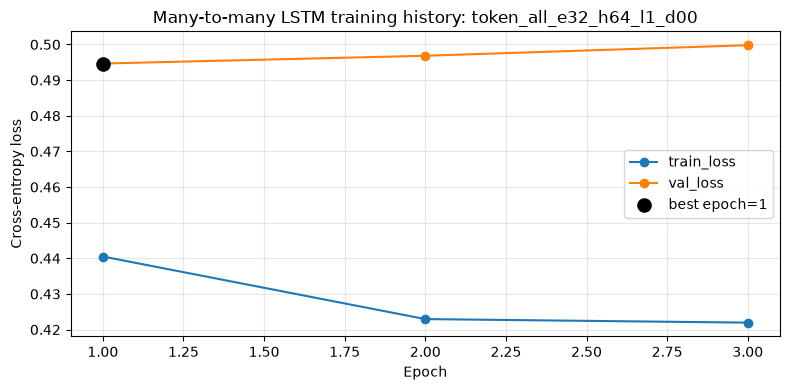

In [3]:
history_df = pd.DataFrame({key: value for key, value in history.items() if isinstance(value, list)})
display(history_df.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history_df['epoch'], history_df['train_loss'], marker='o', label='train_loss')
ax.plot(history_df['epoch'], history_df['val_loss'], marker='o', label='val_loss')

best_epoch = history.get('best_epoch')
if best_epoch is not None:
    best_row = history_df[history_df['epoch'] == best_epoch].iloc[0]
    ax.scatter(best_row['epoch'], best_row['val_loss'], s=90, color='black', zorder=5, label=f'best epoch={best_epoch}')

ax.set_title(f'Many-to-many LSTM training history: {RUN_NAME}')
ax.set_xlabel('Epoch')
ax.set_ylabel('Cross-entropy loss')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_training_loss.png', dpi=150)
plt.show()

**Промежуточный вывод.** Early stopping выбирает checkpoint на 1-й эпохе: дальше `train_loss` снижается, но `val_loss` растёт. Это указывает на быстрое переобучение next-token задачи даже для baseline-архитектуры.

## 4 Сравнение scoring strategies

,strategy,threshold,f1,precision,recall,fpr,average_precision,fp,fn
5,nll_max,8.4257,0.8871,0.9625,0.8227,0.0043,0.9509,240,1326
2,topk_last3,0.0784,0.6281,0.7017,0.5684,0.0324,0.5975,1808,3228
1,topk_all,0.0909,0.5756,0.7671,0.4606,0.0187,0.6267,1046,4035
0,topk_last,0.1034,0.5699,0.8529,0.4279,0.0099,0.5607,552,4279
4,nll_p95,5.5183,0.5506,0.8582,0.4053,0.0090,0.6443,501,4448
3,nll_mean,1.0443,0.5350,0.8564,0.3890,0.0087,0.6613,488,4570


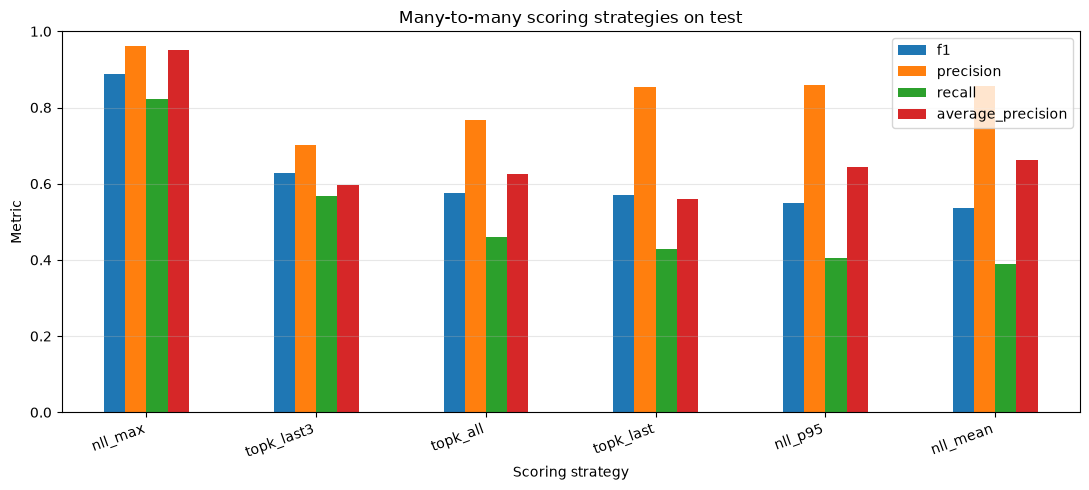

In [4]:
test_order = test_metrics.sort_values('f1', ascending=False)['strategy'].tolist()
test_plot = test_metrics.copy()
test_plot['strategy'] = pd.Categorical(test_plot['strategy'], categories=test_order, ordered=True)
test_plot = test_plot.sort_values('strategy')

display(test_plot[['strategy', 'threshold', 'f1', 'precision', 'recall', 'fpr', 'average_precision', 'fp', 'fn']].round(4))

plot_columns = ['f1', 'precision', 'recall', 'average_precision']
ax = test_plot.set_index('strategy')[plot_columns].plot(kind='bar', figsize=(11, 5))
ax.set_title('Many-to-many scoring strategies on test')
ax.set_xlabel('Scoring strategy')
ax.set_ylabel('Metric')
ax.set_ylim(0, 1)
ax.grid(axis='y', alpha=0.3)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_scoring_test_metrics.png', dpi=150)
plt.show()

**Промежуточный вывод.** `nll_max` лучше остальных стратегий по F1, precision, recall и average precision одновременно. Среди top-k вариантов лучше всего выглядит `topk_last3`, но его качество всё равно заметно ниже `nll_max`. Значит, ключевое улучшение даёт не само попадание/непопадание в top-k, а использование вероятности истинного события.

## 5 Ошибки и FPR

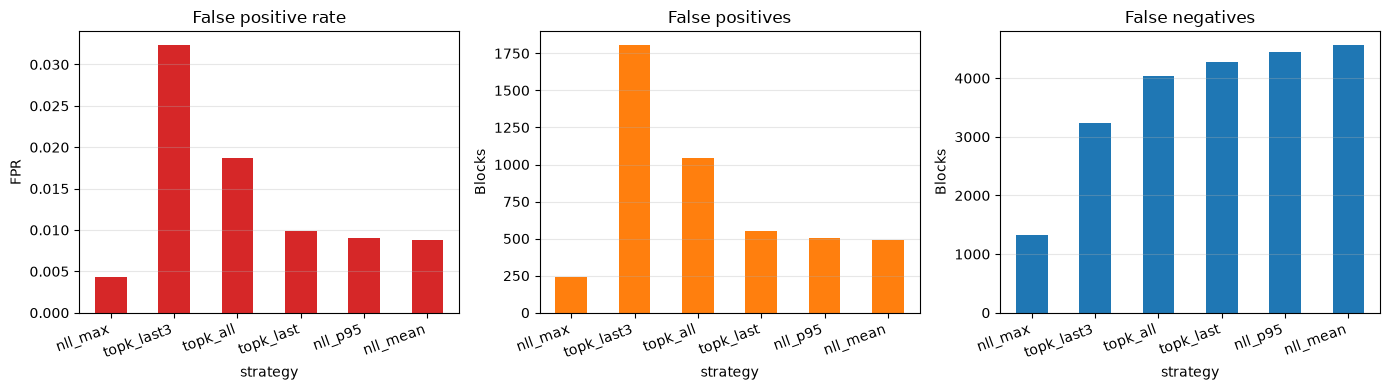

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

test_plot.set_index('strategy')['fpr'].plot(kind='bar', ax=axes[0], color='tab:red')
axes[0].set_title('False positive rate')
axes[0].set_ylabel('FPR')
axes[0].grid(axis='y', alpha=0.3)

test_plot.set_index('strategy')['fp'].plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].set_title('False positives')
axes[1].set_ylabel('Blocks')
axes[1].grid(axis='y', alpha=0.3)

test_plot.set_index('strategy')['fn'].plot(kind='bar', ax=axes[2], color='tab:blue')
axes[2].set_title('False negatives')
axes[2].set_ylabel('Blocks')
axes[2].grid(axis='y', alpha=0.3)

for ax in axes:
    ax.tick_params(axis='x', rotation=20)
    for label in ax.get_xticklabels():
        label.set_ha('right')

plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_scoring_errors.png', dpi=150)
plt.show()

**Промежуточный вывод.** `nll_max` одновременно держит минимальный FPR и сильно снижает число false negatives относительно остальных стратегий. `nll_mean` и `nll_p95` тоже дают мало false positives, но пропускают слишком много аномалий, потому что сглаживают экстремальные переходы.

## 6 Confusion matrices

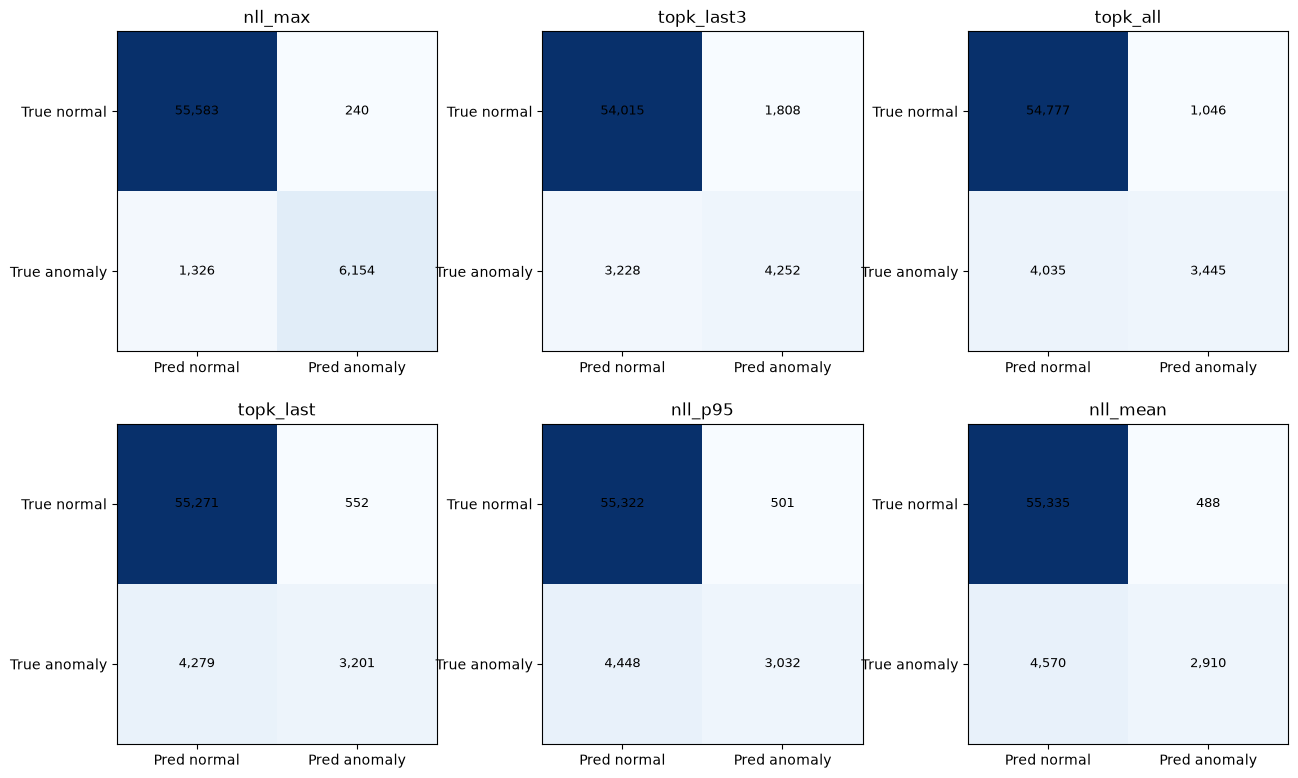

In [6]:
def plot_confusion_from_row(row: pd.Series, ax):
    matrix = np.array([[row['tn'], row['fp']], [row['fn'], row['tp']]], dtype=int)
    ax.imshow(matrix, cmap='Blues')
    ax.set_title(row['strategy'])
    ax.set_xticks([0, 1], labels=['Pred normal', 'Pred anomaly'])
    ax.set_yticks([0, 1], labels=['True normal', 'True anomaly'])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{matrix[i, j]:,}', ha='center', va='center', color='black', fontsize=9)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, (_, row) in zip(axes.ravel(), test_plot.iterrows()):
    plot_confusion_from_row(row, ax)
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_scoring_confusion_matrices.png', dpi=150)
plt.show()

**Промежуточный вывод.** Confusion matrices показывают, что top-k стратегии либо пропускают много аномалий, либо дают больше ложных тревог. `nll_max` лучше балансирует ошибки: при очень малом количестве FP он сохраняет высокий TP.

## 7 Распределения score

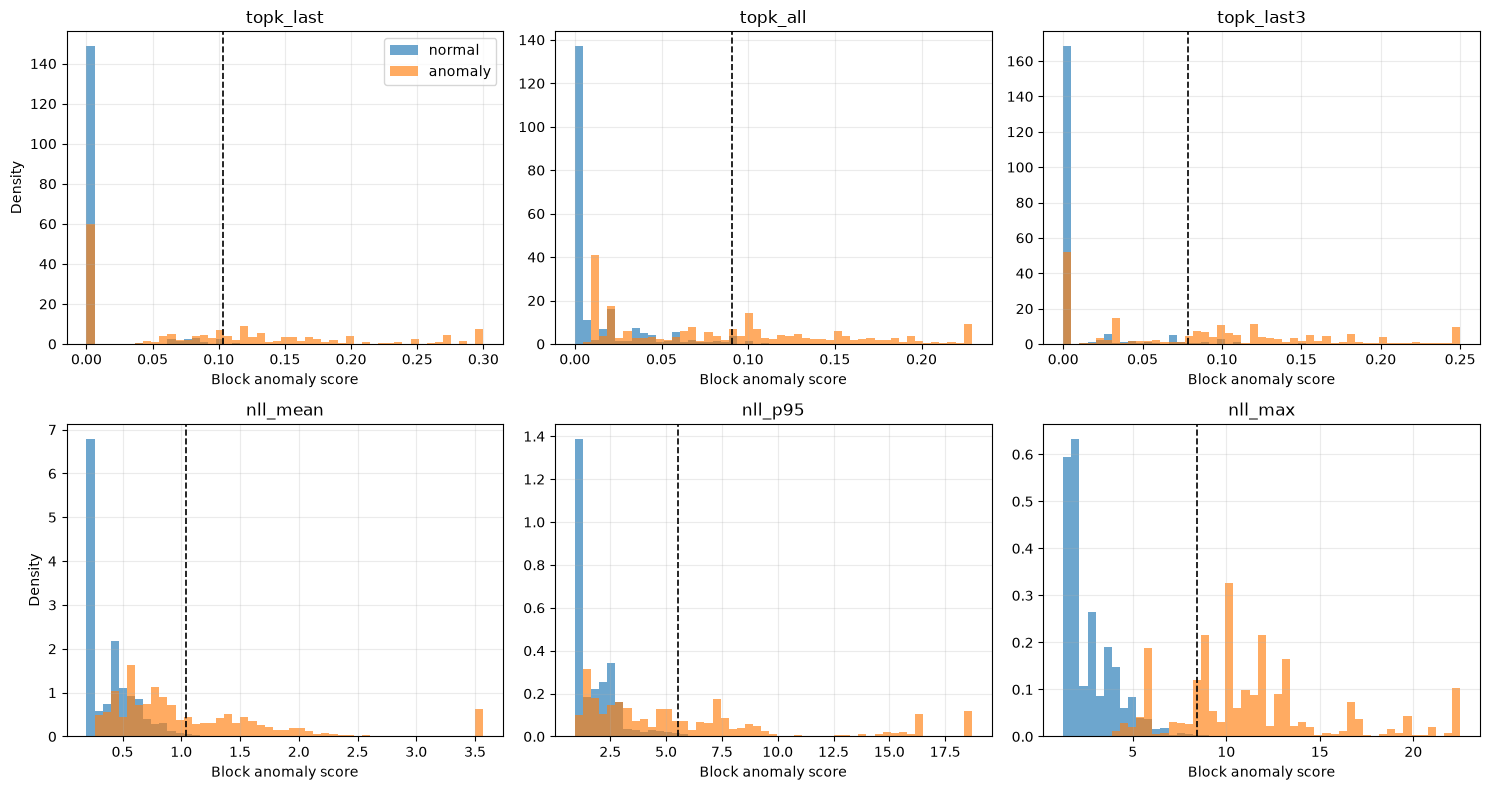

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, strategy in zip(axes.ravel(), STRATEGIES):
    frame = scores['test'][strategy]
    normal = frame.loc[frame['y_true'] == 0, 'score']
    anomaly = frame.loc[frame['y_true'] == 1, 'score']
    threshold = float(thresholds.loc[thresholds['strategy'] == strategy, 'threshold'].iloc[0])
    upper = np.quantile(frame['score'], 0.995)
    lower = frame['score'].min()
    bins = np.linspace(lower, upper, 50) if upper > lower else 30
    ax.hist(normal.clip(upper=upper), bins=bins, alpha=0.65, density=True, label='normal')
    ax.hist(anomaly.clip(upper=upper), bins=bins, alpha=0.65, density=True, label='anomaly')
    ax.axvline(threshold, color='black', linestyle='--', linewidth=1.2)
    ax.set_title(strategy)
    ax.set_xlabel('Block anomaly score')
    ax.grid(alpha=0.25)
axes[0, 0].set_ylabel('Density')
axes[1, 0].set_ylabel('Density')
axes[0, 0].legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_scoring_score_distributions.png', dpi=150)
plt.show()

In [8]:
def score_quantiles(frame: pd.DataFrame) -> pd.DataFrame:
    quantiles = [0.0, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 1.0]
    return (
        frame.groupby('y_true')['score']
        .quantile(quantiles)
        .unstack()
        .rename(index={0: 'normal', 1: 'anomaly'})
    )

for strategy in ['topk_last', 'topk_last3', 'nll_mean', 'nll_p95', 'nll_max']:
    print(strategy)
    display(score_quantiles(scores['test'][strategy]).round(4))

topk_last


,0.00,0.25,0.50,0.75,0.90,0.95,0.99,1.00
y_true,,,,,,,,
normal,0.0,0.0,0.0000,0.00,0.00,0.0769,0.1,0.4
anomaly,0.0,0.0,0.0909,0.15,0.25,0.2857,0.5,1.0


topk_last3


,0.00,0.25,0.50,0.75,0.90,0.95,0.99,1.00
y_true,,,,,,,,
normal,0.0,0.0,0.000,0.000,0.0278,0.0667,0.1111,0.303
anomaly,0.0,0.0,0.087,0.129,0.1875,0.2425,0.3611,1.000


nll_mean


,0.00,0.25,0.50,0.75,0.90,0.95,0.99,1.00
y_true,,,,,,,,
normal,0.1930,0.2081,0.2642,0.4960,0.6634,0.7919,1.0207,2.5719
anomaly,0.3221,0.5723,0.8505,1.4096,1.9691,2.7085,5.6219,11.6458


nll_p95


,0.00,0.25,0.50,0.75,0.90,0.95,0.99,1.00
y_true,,,,,,,,
normal,0.9120,0.9829,1.1280,2.4106,2.8316,3.9149,5.4551,12.3656
anomaly,1.2468,2.2731,4.6642,7.3657,15.1741,16.4452,21.8166,22.7953


nll_max


,0.00,0.25,0.50,0.75,0.90,0.95,0.99,1.00
y_true,,,,,,,,
normal,1.2763,1.2763,2.1296,3.6209,4.6891,5.4567,7.3682,14.4984
anomaly,3.9398,8.6550,10.4508,13.1032,17.0952,20.8475,23.8782,28.8292


**Промежуточный вывод.** У `nll_max` распределения normal/anomaly разделены значительно лучше. Это согласуется с гипотезой, что аномальный блок часто содержит хотя бы один резко неожиданный переход. Средние и percentile-агрегаты частично сглаживают такой переход, а top-k стратегии теряют информацию о степени неожиданности.

## 8 Precision-recall curves

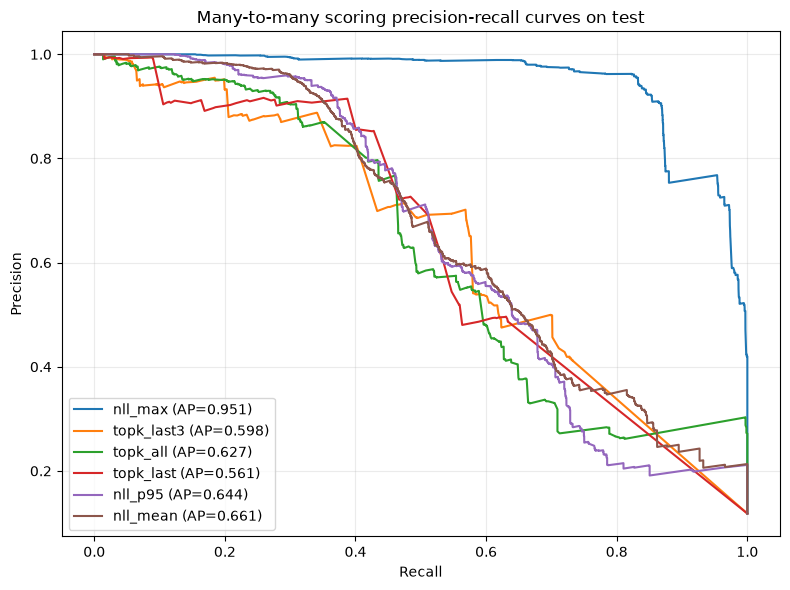

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for strategy in test_order:
    frame = scores['test'][strategy]
    precision, recall, _ = precision_recall_curve(frame['y_true'], frame['score'])
    ap = float(test_metrics.loc[test_metrics['strategy'] == strategy, 'average_precision'].iloc[0])
    ax.plot(recall, precision, label=f'{strategy} (AP={ap:.3f})')
ax.set_title('Many-to-many scoring precision-recall curves on test')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_scoring_pr_curves.png', dpi=150)
plt.show()

**Промежуточный вывод.** PR-кривые подтверждают преимущество `nll_max`: эта стратегия сохраняет высокий precision на широком диапазоне recall и имеет максимальный average precision. Это значит, что `nll_max` лучше не только при выбранном threshold, но и как ranking score.

## 9 Детальный разбор лучшей стратегии

In [10]:
BEST_STRATEGY = test_metrics.sort_values('f1', ascending=False).iloc[0]['strategy']
best_threshold = float(thresholds.loc[thresholds['strategy'] == BEST_STRATEGY, 'threshold'].iloc[0])
best_scores = scores['test'][BEST_STRATEGY].copy()
best_scores['y_pred'] = (best_scores['score'] >= best_threshold).astype(int)
best_scores['error_type'] = np.select(
    [
        (best_scores['y_true'] == 0) & (best_scores['y_pred'] == 1),
        (best_scores['y_true'] == 1) & (best_scores['y_pred'] == 0),
        (best_scores['y_true'] == 1) & (best_scores['y_pred'] == 1),
        (best_scores['y_true'] == 0) & (best_scores['y_pred'] == 0),
    ],
    ['FP', 'FN', 'TP', 'TN'],
    default='unknown',
)

print('Best strategy:', BEST_STRATEGY)
print('Threshold:', round(best_threshold, 4))
display(best_scores['error_type'].value_counts().reindex(['TN', 'FP', 'FN', 'TP']).fillna(0).astype(int).to_frame('count'))

print('Top false positives by score')
display(best_scores[best_scores['error_type'] == 'FP'].sort_values('score', ascending=False).head(15))

print('False negatives with the lowest scores')
display(best_scores[best_scores['error_type'] == 'FN'].sort_values('score', ascending=True).head(15))

Best strategy: nll_max
Threshold: 8.4257


,count
error_type,
TN,55583
FP,240
FN,1326
TP,6154


Top false positives by score


,block_id,y_true,num_windows,score,window_score_max,y_pred,error_type
29923,blk_-9156790754752134682,0,24,14.498392,14.498392,1,FP
11361,blk_-4089867055268305673,0,11,14.057120,14.057120,1,FP
20517,blk_-6597256551322449820,0,24,13.883058,13.883058,1,FP
37151,blk_2817490767587518880,0,20,13.274368,13.274368,1,FP
5546,blk_-2509051259281590442,0,10,13.099763,13.099763,1,FP
26936,blk_-8330387606209239875,0,10,12.913093,12.913093,1,FP
45133,blk_5002772342083912894,0,11,12.913093,12.913093,1,FP
13514,blk_-4706229462686572756,0,11,12.913093,12.913093,1,FP
50724,blk_647656174817437280,0,212,12.799044,12.799044,1,FP
8917,blk_-3410519084840469999,0,212,12.799044,12.799044,1,FP


False negatives with the lowest scores


,block_id,y_true,num_windows,score,window_score_max,y_pred,error_type
62258,blk_9061925472135159783,1,18,3.939848,3.939848,0,FN
60161,blk_8621839627868916093,1,16,3.939848,3.939848,0,FN
60086,blk_8606262182309864566,1,16,3.939848,3.939848,0,FN
59340,blk_8451960762770212708,1,18,3.939848,3.939848,0,FN
52328,blk_6861776981849859756,1,14,3.939848,3.939848,0,FN
59121,blk_8407740633807599692,1,16,3.939848,3.939848,0,FN
59117,blk_8406844264869509970,1,18,3.939848,3.939848,0,FN
59328,blk_8449324691093002833,1,18,3.958194,3.958194,0,FN
61281,blk_8868914713718928327,1,16,3.958194,3.958194,0,FN
61818,blk_8973590052978388634,1,18,3.958194,3.958194,0,FN


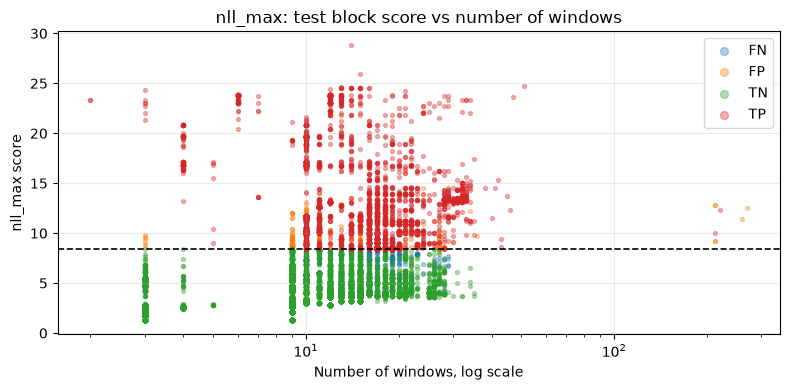

,blocks,score_mean,score_median,windows_median,windows_p95
error_type,,,,,
TN,55583,2.6862,2.1296,9.0,18.0
FP,240,9.5912,9.1671,12.0,28.0
FN,1326,6.0931,5.8226,10.0,20.0
TP,6154,12.5188,11.5357,15.0,31.0


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
for error_type, group in best_scores.groupby('error_type'):
    ax.scatter(group['num_windows'], group['score'], s=8, alpha=0.35, label=error_type)
ax.axhline(best_threshold, color='black', linestyle='--', linewidth=1.2)
ax.set_xscale('log')
ax.set_xlabel('Number of windows, log scale')
ax.set_ylabel(f'{BEST_STRATEGY} score')
ax.set_title(f'{BEST_STRATEGY}: test block score vs number of windows')
ax.grid(alpha=0.25)
ax.legend(markerscale=2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'many_to_many_best_score_vs_num_windows.png', dpi=150)
plt.show()

summary_by_error = (
    best_scores.groupby('error_type')
    .agg(
        blocks=('block_id', 'size'),
        score_mean=('score', 'mean'),
        score_median=('score', 'median'),
        windows_median=('num_windows', 'median'),
        windows_p95=('num_windows', lambda s: s.quantile(0.95)),
    )
    .reindex(['TN', 'FP', 'FN', 'TP'])
)
display(summary_by_error.round(4))

**Промежуточный вывод.** У лучшей стратегии остаются ошибки, но они существенно меньше, чем у остальных scoring variants. False positives - нормальные блоки с резким неожиданным переходом, а false negatives - аномальные блоки без достаточно высокого single-transition NLL. Это естественное ограничение `nll_max`: стратегия хорошо ловит локальные нарушения, но может пропустить более мягкие аномалии.

## Итоговый вывод

На baseline-архитектуре many-to-many LSTM top-k стратегии не дают существенного преимущества над one-step baseline. Например, `topk_last` концептуально ближе всего к one-step top-k miss scoring, но на test split получает только `F1 ≈ 0.570`. Лучший top-k вариант, `topk_last3`, достигает `F1 ≈ 0.628`, что всё ещё ниже one-step baseline (`F1 ≈ 0.706`). Это показывает, что простой переход к many-to-many обучению сам по себе не гарантирует улучшение при грубом top-k scoring.

Среди всех проверенных scoring strategies лучшей является `nll_max`: она достигает `F1 ≈ 0.887`, `precision ≈ 0.963`, `recall ≈ 0.823`, `FPR ≈ 0.004`, `average precision ≈ 0.951` на test split. Это заметно лучше всех top-k стратегий.

Главный вывод: для HDFS anomaly detection важен не средний уровень неожиданности по блоку, а наличие хотя бы одного резко непривычного перехода. Именно поэтому `nll_max` сильно превосходит `nll_mean`, `nll_p95` и top-k стратегии. Дальше имеет смысл зафиксировать `nll_max` как основную scoring strategy и уже с ней проводить эксперименты с архитектурой many-to-many LSTM.